# Simulated Study for Monte Carlo Dropout and Dropblock methods

## 1. Dropout

### a) How it works

Let us first try to understand how dropout layers work. We first import numpy, keras (through tensorflow), and other relevant packages.

In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import the numpy package
import numpy as np

# Import tensorflow and keras
# Tested on tensorflow version 2.10.0
import tensorflow as tf
from tensorflow import keras as keras

# Check if tensorflow is running on gpu, in case you have a dedicated graphic card on your PC
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
data = np.arange(10).reshape(5, 2).astype(np.float32)+1
print(data)

[[ 1.  2.]
 [ 3.  4.]
 [ 5.  6.]
 [ 7.  8.]
 [ 9. 10.]]


In [5]:
tf.random.set_seed(2023) # set seed for reproducibility
# Syntax: tf.keras.layers.Dropout(rate, noise_shape=None, seed=None, **kwargs)

layer = tf.keras.layers.Dropout(0.5, input_shape=(2,)) 
outputs = layer(data, training=True)
print(outputs)

tf.Tensor(
[[ 2.  0.]
 [ 0.  8.]
 [ 0. 12.]
 [ 0. 16.]
 [ 0. 20.]], shape=(5, 2), dtype=float32)


 #### Exercise: Change the dropout rate above and observe the differences in the outcomes.

### b) Simulated Study

For our study, we simulate a data set where input $X$ contains $N=100$ data sets, with $80$ sets for training and $20$ for testing, each has $100$ features of your choice (we use uniform $U(0,1)$ here but it shouldn't matter; 
Our model has only one hidden layer, given by $Y=g(XW)\beta+\epsilon$, where $g$ is hyperbolic tangent $g(x)=\tanh(x)$;
$W$ has five nodes, epsilon is normal $N(0,\sigma^2)$ with $\sigma=2$. 

In [7]:
N = 100 # number of data sets
n = 100 # number of points in one set
nodes = 5 # number of nodes in the hidden layer
feat = 1 # number of features observed for the output, here we assume single output 

# set seed
np.random.seed(2023)

# you can change to any distribution you like: random.uniform, random.normal, random.binomial (Bernoulli)
X = np.random.uniform(high=1, low=-1, size=(N,n))
# append a column of ones for X, which corresponds to the "bias" for the weight matrix
Xdesign = np.c_[np.ones(N),X]

# the weight as your desire, 
W = np.random.uniform(high=1, low=0, size=(n+1,nodes)) 
# don't forget to normalize W
W=W/(W.sum(axis=0))

# the beta
beta = np.random.randint(7, size=(nodes,feat))-3 # integers from -3 to 3
# normal errors
epsilon = np.random.normal(loc = 0, scale = 4, size = feat)

# the simulated output
Y=np.tanh(Xdesign@W)@beta + epsilon

Let's plot the data and see what happen

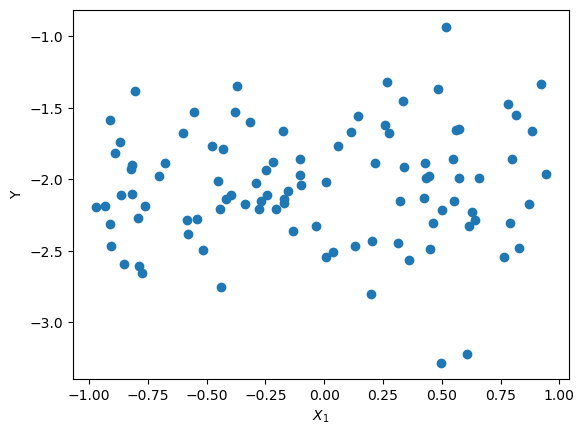

In [8]:
import matplotlib.pyplot as plt 

plt.clf() # clear plot
plt.plot(X[:,1],Y,'o')
plt.xlabel('$X_1$')
plt.ylabel('Y');

Next we will split our data into two sets, 80% for training and 20% for testing

In [9]:
(Xtrain,Xtest) = (X[range(int(0.8*N)),:], X[int(0.8*N):N,:])
(Ytrain,Ytest) = (Y[range(int(0.8*N))], Y[int(0.8*N):N])

Now, we build two models, one with dropout and one without using the training set, and test which give a better prediction

In [10]:
# keras dependencies
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense

# the first model without dropout
model_nodrop = Sequential()
model_nodrop.add(InputLayer(input_shape=(n,)))
model_nodrop.add(Dense(50, use_bias=True, bias_initializer='zeros')) 
model_nodrop.add(Dense(1, use_bias=True, bias_initializer='zeros'))  #input dimension equal the number of features
model_nodrop.compile(loss='mse', optimizer='adam')

model_nodrop.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 50)                5050      
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 5,101
Trainable params: 5,101
Non-trainable params: 0
_________________________________________________________________


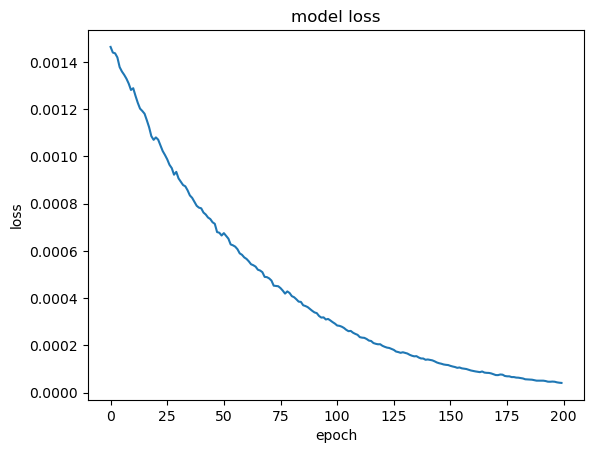

In [55]:
# train model, and plot the loss function

# uncomment to see how much time is taken to train
#from time import time as tm
#tm1=tm()
history = model_nodrop.fit(Xtrain, Ytrain, epochs=200, verbose=0)
#tm2=tm()
#print(tm2-tm1)

# summarize history for loss
plt.clf()
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

3/3 [==============================] - 0s 5ms/step - loss: 3.8855e-05
Errors: 0.00%


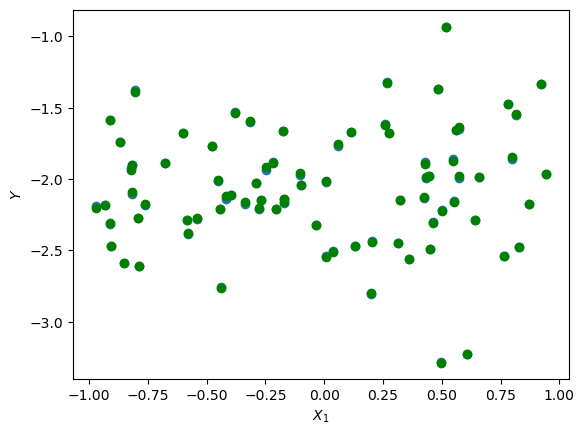

In [56]:
# It fits the training set pretty well
y_pred_nodrop = model_nodrop.predict(Xtrain)
plt.clf() #clearplot

plt.plot(Xtrain[:,1],Ytrain,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtrain[:,1])
plt.plot(Xtrain[:,1][ind_plot],y_pred_nodrop[ind_plot],'o',color="green"); # comment this line to see the actual data (blue)

accuracy_nodrop_train = model_nodrop.evaluate(Xtrain, Ytrain)
print('Errors: %.2f%%' % (accuracy_nodrop_train*100))

1/1 [==============================] - 0s 36ms/step - loss: 4.3466
Errors: 434.66%


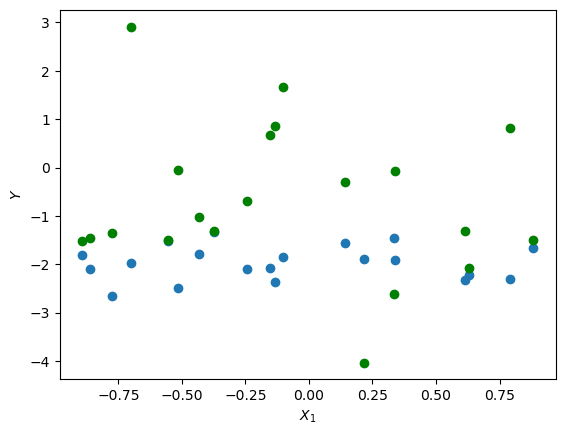

In [57]:
# But it barely fits the test
y_pred_nodrop = model_nodrop.predict(Xtest)
plt.clf() #clearplot

plt.plot(Xtest[:,1],Ytest,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtest[:,1])
plt.plot(Xtest[:,1][ind_plot],y_pred_nodrop[ind_plot],'o',color="green"); # comment this line to see the actual data (blue)

accuracy_nodrop_test = model_nodrop.evaluate(Xtest, Ytest)
print('Errors: %.2f%%' % (accuracy_nodrop_test*100))

Now we add some dropout layers, compare the time and the loss with the previous model

In [58]:
from tensorflow.keras.layers import Dropout

# By default, Dropout has training=True for MC Dropout, 
# We define a class StandardDropout that does not apply dropout during inference

model_drop = Sequential()
model_drop.add(InputLayer(input_shape=(n,)))
model_drop.add(StandardDropout(0.5)) # Replace this by model_drop.add(StandardDropout(0.2))
model_drop.add(Dense(50, use_bias=True, bias_initializer='zeros')) 
model_drop.add(StandardDropout(0.8)) # Replace this by model_drop.add(StandardDropout(0.2))
model_drop.add(Dense(1, use_bias=True, bias_initializer='zeros')) 
model_drop.compile(loss='mse', optimizer='adam')

model_drop.summary()

tf.Tensor(
[[ 0.  4.]
 [ 0.  0.]
 [10.  0.]
 [ 0. 16.]
 [ 0.  0.]], shape=(5, 2), dtype=float32)
Model: "sequential_29"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 standard_dropout_7 (Standar  (None, 100)              0         
 dDropout)                                                       
                                                                 
 dense_56 (Dense)            (None, 50)                5050      
                                                                 
 standard_dropout_8 (Standar  (None, 50)               0         
 dDropout)                                                       
                                                                 
 dense_57 (Dense)            (None, 1)                 51        
                                                                 
Total params: 5,101
Trainable params: 5,101
Non-trainable params: 0
____________________

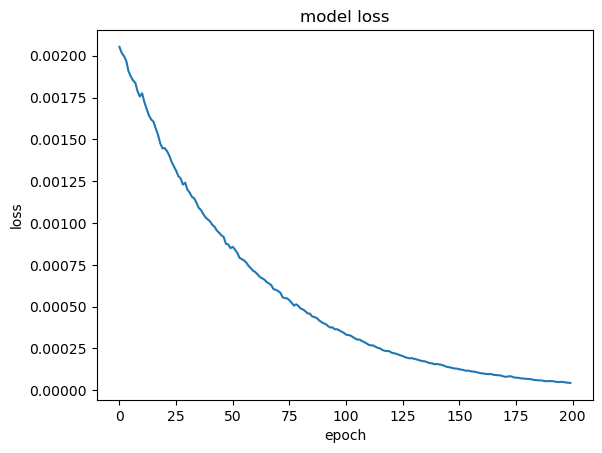

In [62]:
# train model, and plot the loss function

# uncomment to see how much time is taken to train
#from time import time as tm
#tm1=tm()
historydrop = model_drop.fit(Xtrain, Ytrain, epochs=200, verbose=0)
#tm2=tm()
#print(tm2-tm1)

# summarize history for loss
plt.clf()
plt.plot(historydrop.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

3/3 [==============================] - 0s 6ms/step - loss: 4.1699e-05
Errors: 0.00%


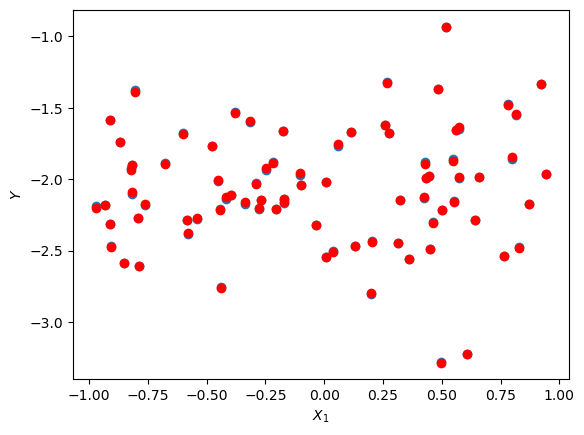

In [63]:
# Trained data with dropout
y_pred_drop = model_drop.predict(Xtrain)
plt.clf() #clearplot

plt.plot(Xtrain[:,1],Ytrain,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtrain[:,1])
plt.plot(Xtrain[:,1][ind_plot],y_pred_drop[ind_plot],'o',color="red"); # comment this line to see the actual data (blue)

accuracy_drop_train = model_drop.evaluate(Xtrain, Ytrain)
print('Errors: %.2f%%' % (accuracy_drop_train*100))

1/1 [==============================] - 0s 33ms/step - loss: 4.5198
Errors: 451.98%


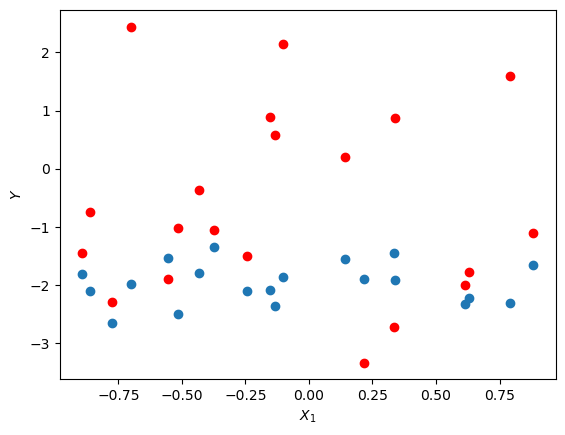

In [64]:
# Test data
y_pred_drop = model_drop.predict(Xtest)

plt.clf() #clearplot

plt.plot(Xtest[:,1],Ytest,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtest[:,1])
plt.plot(Xtest[:,1][ind_plot],y_pred_drop[ind_plot],'o',color="red"); # comment this line to see the actual data (blue)

accuracy_drop_test = model_drop.evaluate(Xtest, Ytest)
print('Errors: %.2f%%' % (accuracy_drop_test*100))

Let's compute the residuals of both models and see which one is smaller

In [19]:
# Once again let's contemplate the power of dropout by looking at the test errors
print(accuracy_nodrop_test," ",accuracy_drop_test)

3.7443833351135254   0.9870367050170898


#### Exercise: Replace Dropout by StandardDropout in the codes above, and compare the result with the Monte Carlo Dropout method

## c) Gaussian Dropout 

Syntax: tf.keras.layers.GaussianDropout(rate, seed=None, **kwargs)

As it is a regularization layer, it is only active at training time.

In [21]:
from keras.layers import GaussianDropout

model_Gaussdrop = Sequential()
model_Gaussdrop.add(InputLayer(input_shape=(n,)))
model_Gaussdrop.add(GaussianDropout(0.2))
model_Gaussdrop.add(Dense(50, use_bias=True, bias_initializer='zeros')) 
model_Gaussdrop.add(GaussianDropout(0.2)) 
model_Gaussdrop.add(Dense(1, use_bias=True, bias_initializer='zeros')) 
model_Gaussdrop.compile(loss='mse', optimizer='adam')

model_Gaussdrop.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_dropout (GaussianD  (None, 100)              0         
 ropout)                                                         
                                                                 
 dense_4 (Dense)             (None, 50)                5050      
                                                                 
 gaussian_dropout_1 (Gaussia  (None, 50)               0         
 nDropout)                                                       
                                                                 
 dense_5 (Dense)             (None, 1)                 51        
                                                                 
Total params: 5,101
Trainable params: 5,101
Non-trainable params: 0
_________________________________________________________________


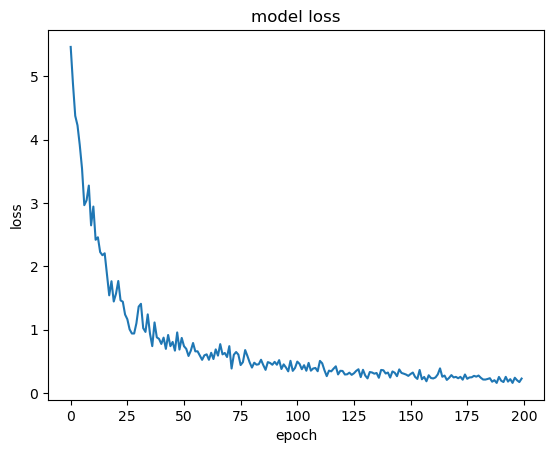

In [22]:
# train model, and plot the loss function

# uncomment to see how much time is taken to train
#from time import time as tm
#tm1=tm()
historyGaussdrop = model_Gaussdrop.fit(Xtrain, Ytrain, epochs=200, verbose=0)
#tm2=tm()
#print(tm2-tm1)

# summarize history for loss
plt.clf()
plt.plot(historyGaussdrop.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

3/3 [==============================] - 0s 5ms/step - loss: 0.0249
Errors: 2.49%


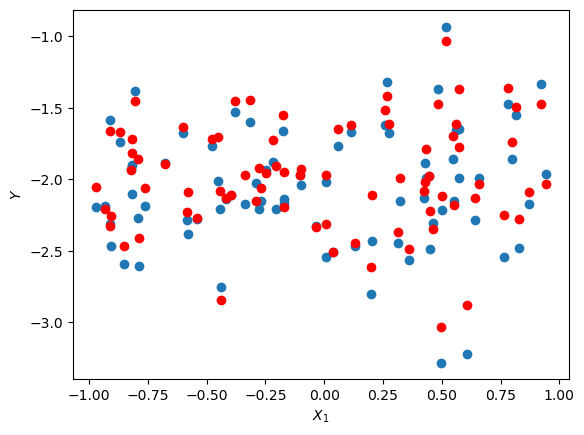

In [23]:
# Trained data with dropout
y_pred_drop = model_Gaussdrop.predict(Xtrain)
plt.clf() #clearplot

plt.plot(Xtrain[:,1],Ytrain,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtrain[:,1])
plt.plot(Xtrain[:,1][ind_plot],y_pred_drop[ind_plot],'o',color="red"); # comment this line to see the actual data (blue)

accuracy_drop_train = model_Gaussdrop.evaluate(Xtrain, Ytrain)
print('Errors: %.2f%%' % (accuracy_drop_train*100))

1/1 [==============================] - 0s 31ms/step - loss: 0.4702
Errors: 47.02%


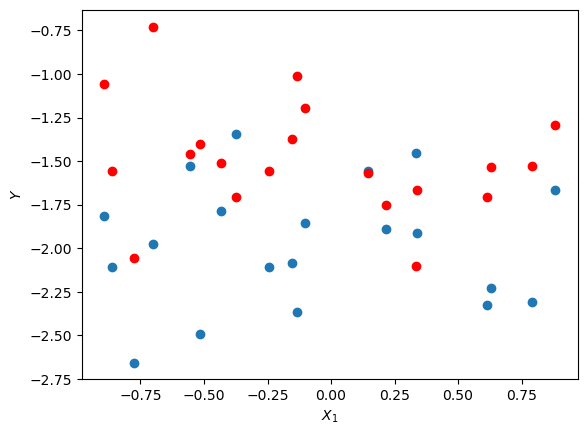

In [24]:
# Test data
y_pred_drop = model_Gaussdrop.predict(Xtest)

plt.clf() #clearplot

plt.plot(Xtest[:,1],Ytest,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtest[:,1])
plt.plot(Xtest[:,1][ind_plot],y_pred_drop[ind_plot],'o',color="red"); # comment this line to see the actual data (blue)

accuracy_drop_test = model_Gaussdrop.evaluate(Xtest, Ytest)
print('Errors: %.2f%%' % (accuracy_drop_test*100))

# 2. Dropblock

## a) How it works

In [25]:
# Tutorial guides retrieved from https://keras.io/api/keras_cv/layers/regularization/dropblock2d/
# with small modifications
# You need to install keras-cv using "conda install -c conda-forge keras-cv"

from keras_cv.layers import DropBlock2D
# We can observe two things:
# 1. A 2x2 block has been dropped
# 2. The inputs have been slightly scaled to account for missing values.

# The number of blocks dropped can vary, between the channels - sometimes no blocks
# will be dropped, and sometimes there will be multiple overlapping blocks.
# Let's present on a larger feature map:

tf.random.set_seed(0) # set seed for reproducibility
features = tf.random.stateless_uniform((1, 4, 4, 100), seed=[0, 1])
layer = DropBlock2D(0.1, (2, 2))
output = layer(features, training=True)

# Play with data number to obtain the following:
print(output[..., 0])  # no drop
print(output[..., 1])  # drop single block
print(output[..., 37])  # drop two blocks
print(output[..., 61])  # drop two blocks with overlap

tf.Tensor(
[[[0.08992183 0.16400029 0.         0.        ]
  [1.0409781  0.2192295  0.         0.        ]
  [0.01583987 0.23314115 0.05909115 0.17255244]
  [1.018385   0.0606546  0.29261675 0.26822644]]], shape=(1, 4, 4), dtype=float32)
tf.Tensor(
[[[0.4479125  0.98060316 0.4637435  0.49189362]
  [0.44887662 0.56565714 0.8428356  0.40326607]
  [0.7643075  0.48214695 0.2932092  0.15311183]
  [0.5488929  0.08532698 1.0455952  0.21264067]]], shape=(1, 4, 4), dtype=float32)
tf.Tensor(
[[[0.38756803 0.33400872 0.         0.        ]
  [0.90066296 0.3150547  0.         0.        ]
  [0.52061003 0.8722086  0.         0.        ]
  [0.6779633  0.9339228  0.         0.        ]]], shape=(1, 4, 4), dtype=float32)
tf.Tensor(
[[[0.9382415  0.24736981 0.         0.        ]
  [0.1122519  0.         0.         0.        ]
  [0.19304012 0.         0.         0.44352484]
  [0.76302814 0.74272573 0.4280234  0.49607673]]], shape=(1, 4, 4), dtype=float32)


#### Exercise: Check all data 1 to 100 to see if any of them drop 3 blocks, overlapping or not.

## b) Simulated Study

Let us reuse the simulated data in part 1. We build a new model using drop block, with layers the same as part (a) except with dropout layers replaced by DropBlock2D.

In [26]:
from keras.layers import Reshape
from keras.layers import Flatten

model_dropblock = Sequential()
model_dropblock.add(InputLayer(input_shape=(n,)))
model_dropblock.add(Reshape((10,10,1)))# Make sure the size is compatible, DropBlock2D requires a 4-tensor input
model_dropblock.add(DropBlock2D(0.1, (5, 5)))
model_dropblock.add(Dense(50,use_bias=True, bias_initializer='zeros')) 
model_dropblock.add(DropBlock2D(0.1, (5, 5)))
model_dropblock.add(Flatten()) 
model_dropblock.add(Dense(1,use_bias=True, bias_initializer='zeros')) 
model_dropblock.compile(loss='mse', optimizer='adam')

model_dropblock.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 10, 10, 1)         0         
                                                                 
 drop_block2d_1 (DropBlock2D  (None, 10, 10, 1)        0         
 )                                                               
                                                                 
 dense_6 (Dense)             (None, 10, 10, 50)        100       
                                                                 
 drop_block2d_2 (DropBlock2D  (None, 10, 10, 50)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 5000)              0         
                                                                 
 dense_7 (Dense)             (None, 1)                

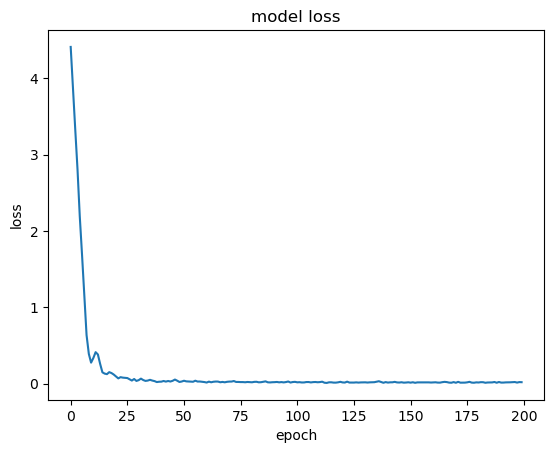

In [27]:
# train model, and plot the loss function
historydropblock = model_dropblock.fit(Xtrain, Ytrain, epochs=200, verbose=0)

# summarize history for loss
plt.clf()
plt.plot(historydropblock.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

1/1 [==============================] - 0s 96ms/step


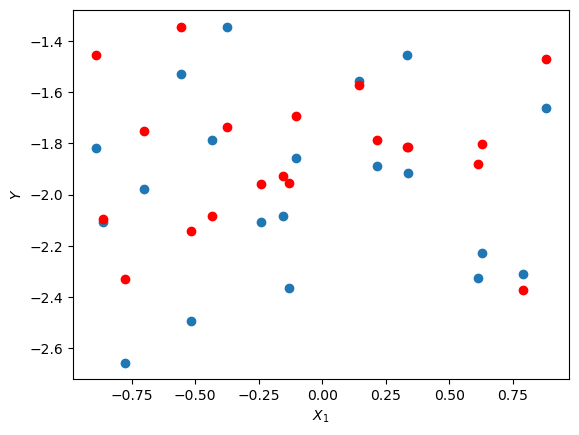

In [23]:
# Test data
y_pred_dropblock = model_dropblock.predict(Xtest)


plt.clf() #clearplot

plt.plot(Xtest[:,1],Ytest,'o')
plt.xlabel('$X_1$')
plt.ylabel('$Y$')


ind_plot=np.argsort(Xtest[:,1])
plt.plot(Xtest[:,1][ind_plot],y_pred_dropblock[ind_plot],'o',color="red"); # comment this line to see the actual data (blue)

In [24]:
accuracy_dropblock_test = model_dropblock.evaluate(Xtest, Ytest)
print('Errors: %.2f%%' % (accuracy_dropblock_test*100))


1/1 [==============================] - 0s 132ms/step - loss: 0.0753
Errors: 7.53%
